In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Introduction:-
This project focuses on predicting medical insurance charges using machine learning algorithms. The dataset contains demographic and medical-related information such as age, BMI, smoking habits, and region. Three machine learning models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were implemented and evaluated using MAE, RMSE, and R² score. Among all models, Random Forest Regressor achieved the best performance.


# Objectives:-
* To analyze medical insurance data.

* To preprocess and visualize the dataset.

* To implement Linear Regression, Decision Tree, and Random Forest models.

* To compare model performance using evaluation metrics.

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Load Dataset

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Medical Cost Personal/insurance.csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


Shape of the Dataset

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Checking Null Values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Checking Duplicate Columns

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis

Target Column

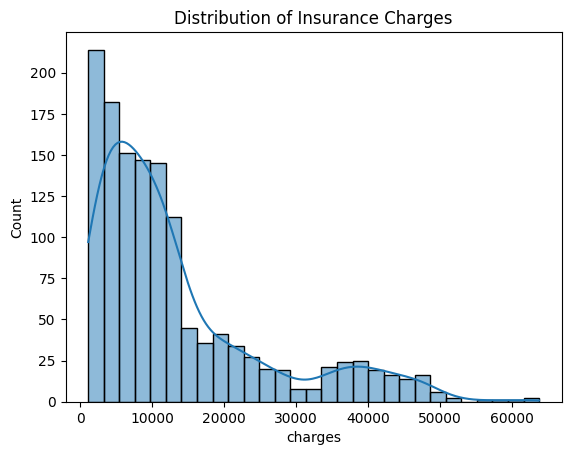

In [ ]:
sns.histplot(df['charges'],kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

Correlation Heatmap

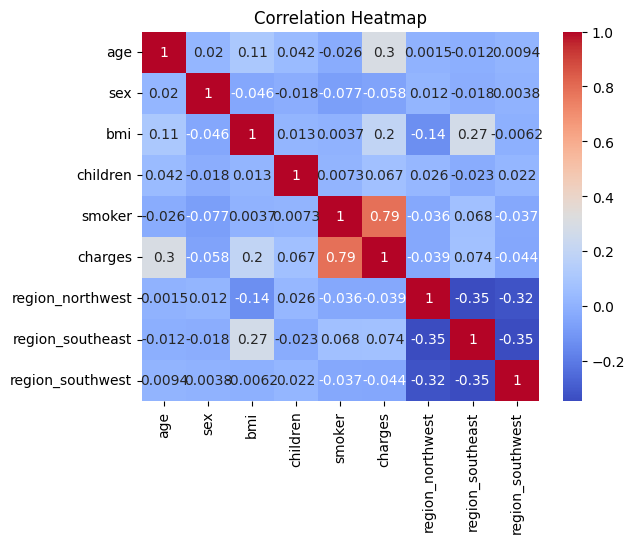

In [ ]:
temp_df = df.copy()

temp_df['sex'] = temp_df['sex'].map({'male':0, 'female':1})
temp_df['smoker'] = temp_df['smoker'].map({'no':0, 'yes':1})

temp_df = pd.get_dummies(temp_df, columns=['region'], drop_first=True)

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Smoker vs Charges

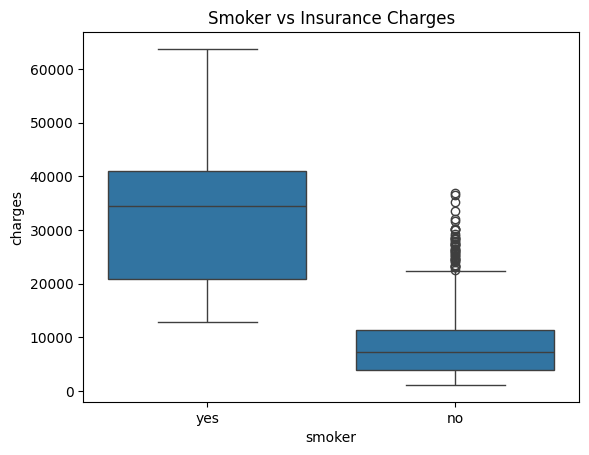

In [ ]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Insurance Charges")
plt.show()

Age vs Charges

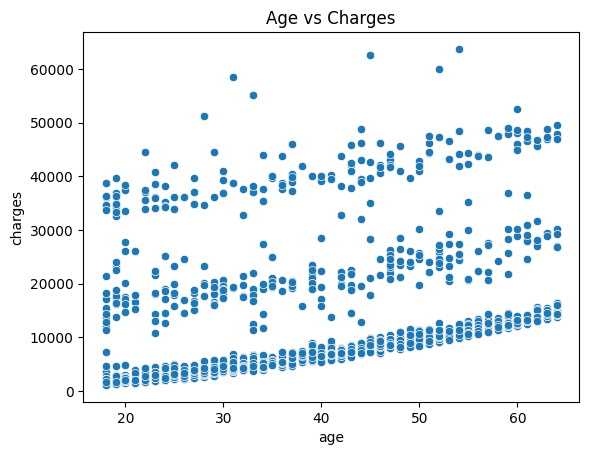

In [ ]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

BMI vs Charges

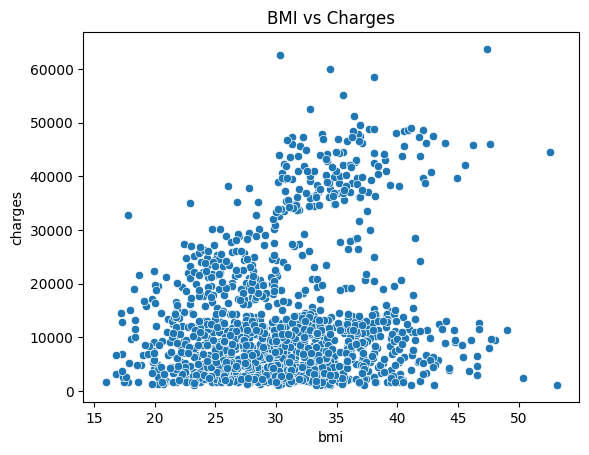

In [ ]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

# Observations:-
* Smokers have much higher charges

* Charges increase with age

* Higher BMI can increase charges

# Data Preprocessing

Encoding Categorical Columns

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Seperate Features and Target

In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

## Train-test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Machine Learning Model used

## Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

## Evaluate Linear Regression

In [ ]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("MSE:", mean_squared_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2 Score:", r2_score(y_test, pred_lr))

Linear Regression Results
MAE: 4177.045561036326
MSE: 35478020.675235614
RMSE: 5956.342894363589
R2 Score: 0.8069287081198011


## Decision Tree

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

## Evaluate Decision Tree

In [ ]:
print("Decision Tree Results")
print("MAE:", mean_absolute_error(y_test, pred_dt))
print("MSE:", mean_squared_error(y_test, pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("R2 Score:", r2_score(y_test, pred_dt))

Decision Tree Results
MAE: 2804.8116326828363
MSE: 34953028.963362776
RMSE: 5912.108673169225
R2 Score: 0.8097857115858496


## Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

## Evaluate random Forest

In [ ]:
print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("MSE:", mean_squared_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2 Score:", r2_score(y_test, pred_rf))

Random Forest Results
MAE: 2663.3287981399258
MSE: 22372575.46335238
RMSE: 4729.965693676052
R2 Score: 0.8782485052664795


# Comparison of all the models

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'R2 Score': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.806929
1      Decision Tree  0.809786
2      Random Forest  0.878249


**Observations:-**
* Random Forest have achieved best R^2 score and lowest error values.
* Random Forest performs best.
* Smoker is the most important feature.
* Linear Regression gives decent baseline results.
* Decision Tree may overfit







## Feature Importance

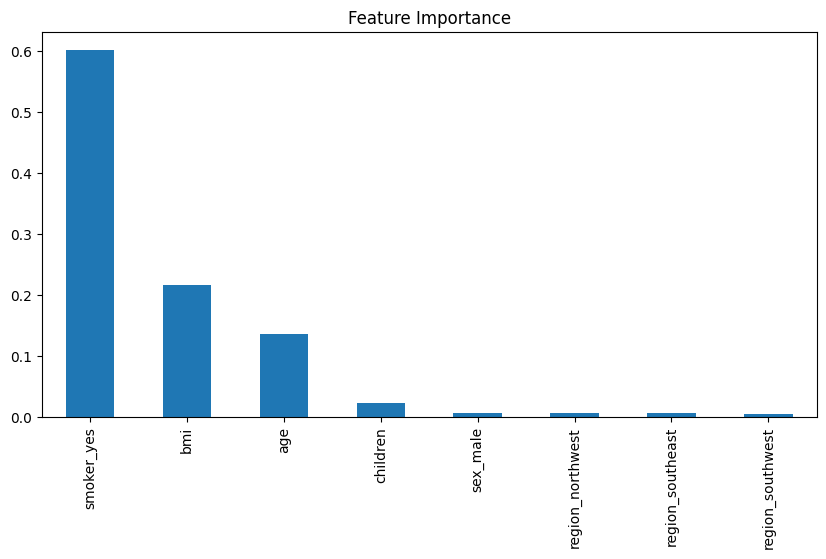

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

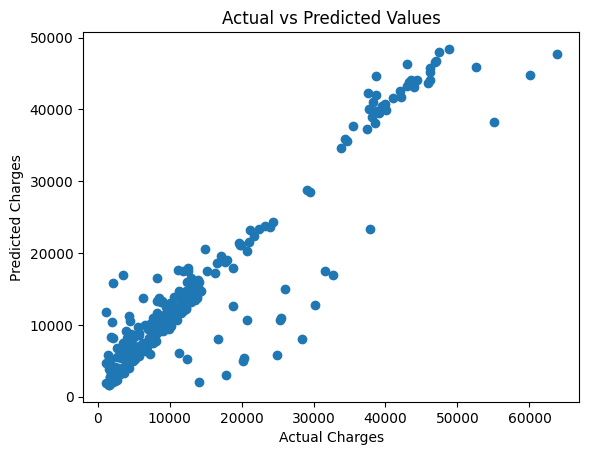

In [ ]:
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Values")
plt.show()

In [ ]:
import joblib

joblib.dump(rf, 'insurance_model.pkl')

['insurance_model.pkl']

# Conclusion:-
This project successfully implemented predictive modeling techniques to estimate medical insurance charges. Among the three algorithms used, Random Forest Regressor provided the best performance. The project demonstrates how machine learning can help insurance companies estimate costs more accurately.